
# RQ1 Notebook — Leakage-Aware Evaluation for Social Bot Detection

This notebook implements **RQ1** from the revised proposal:

> **How does a leakage-aware evaluation protocol influence the measured performance of tabular, graph-based, and hybrid models for social bot detection?**

It is structured to go **step by step from raw data loading to the required RQ1 outputs**:

- **Figure RQ1-a**: grouped comparison of legacy vs leakage-aware performance
- **Figure RQ1-b**: methodological workflow figure
- **Table RQ1-a**: leakage audit summary
- **Table RQ1-b**: benchmark before-vs-after correction

The notebook writes all RQ1 outputs into:

- `outputs/rq1_figures/` for figures
- `outputs/rq1_tables/` for tables

All figures are saved as **PDF** files in addition to PNG.


**Patched version:** this notebook now tries to use **XGBoost** first and automatically falls back to **HistGradientBoostingClassifier** if XGBoost is unavailable or broken in the local environment.

In [ ]:

# Optional dependency note:
# The graph and hybrid sections require torch-geometric.
# If it is missing in your environment, install it first according to your PyTorch version:
#
# pip install torch-geometric
#
# This notebook is written so that the tabular RQ1 pipeline still runs without it.


In [6]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import json
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, average_precision_score, balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

XGB_AVAILABLE = True
try:
    from xgboost import XGBClassifier
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.")
    print("Import error:", e)

# Optional graph imports
PYG_AVAILABLE = True
try:
    import torch
    import torch.nn.functional as F
    from torch import nn
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, SAGEConv, GATConv
    from sklearn.neighbors import kneighbors_graph
except Exception as e:
    PYG_AVAILABLE = False
    print("torch-geometric is not available. Graph and hybrid sections will be skipped until installed.")
    print("Import error:", e)

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
if PYG_AVAILABLE:
    torch.manual_seed(SEED)

# Paths
DATA_PATH = Path("./Data/full_dataset.csv")
BASE_DIR = Path("")
OUT_DIR = BASE_DIR / "outputs"
RQ1_FIG_DIR = OUT_DIR / "rq1_figures"
RQ1_TABLE_DIR = OUT_DIR / "rq1_tables"
RQ1_FIG_DIR.mkdir(parents=True, exist_ok=True)
RQ1_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Feature policy
NUMERIC_FEATURES = [
    "followers_count", "friends_count", "statuses_count",
    "favourites_count", "listed_count"
]
BINARY_FEATURES = [
    "default_profile", "default_profile_image", "geo_enabled"
]
MISSINGNESS_FEATURES = [
    "default_profile_missing", "default_profile_image_missing", "geo_enabled_missing"
]
REVISED_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + MISSINGNESS_FEATURES
LEGACY_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES

print("Ready.")
print("Dataset path:", DATA_PATH)
print("Figure output dir:", RQ1_FIG_DIR)
print("Table output dir:", RQ1_TABLE_DIR)


Ready.
Dataset path: Data/full_dataset.csv
Figure output dir: outputs/rq1_figures
Table output dir: outputs/rq1_tables


## 1. Load the dataset and audit the schema

In [7]:

df = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

required_cols = ["label"] + LEGACY_FEATURES
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

dataset_audit = {
    "n_rows": int(df.shape[0]),
    "n_cols": int(df.shape[1]),
    "label_distribution": df["label"].value_counts(dropna=False).to_dict(),
    "missingness": df[LEGACY_FEATURES].isna().mean().round(4).to_dict(),
    "duplicate_ids": int(df["id"].duplicated().sum()) if "id" in df.columns else None,
    "duplicate_screen_names": int(df["screen_name"].duplicated().sum()) if "screen_name" in df.columns else None
}
dataset_audit


Shape: (14368, 43)

Columns:
['id', 'name', 'screen_name', 'statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'url', 'lang', 'time_zone', 'location', 'default_profile', 'default_profile_image', 'geo_enabled', 'profile_image_url', 'profile_banner_url', 'profile_use_background_image', 'profile_background_image_url_https', 'profile_text_color', 'profile_image_url_https', 'profile_sidebar_border_color', 'profile_background_tile', 'profile_sidebar_fill_color', 'profile_background_image_url', 'profile_background_color', 'profile_link_color', 'utc_offset', 'is_translator', 'follow_request_sent', 'protected', 'verified', 'notifications', 'description', 'contributors_enabled', 'following', 'created_at', 'timestamp', 'crawled_at', 'updated', 'test_set_1', 'test_set_2', 'label']


{'n_rows': 14368,
 'n_cols': 43,
 'label_distribution': {1: 10894, 0: 3474},
 'missingness': {'followers_count': 0.0,
  'friends_count': 0.0,
  'statuses_count': 0.0,
  'favourites_count': 0.0,
  'listed_count': 0.0,
  'default_profile': 0.686,
  'default_profile_image': 0.9946,
  'geo_enabled': 0.7611},
 'duplicate_ids': 0,
 'duplicate_screen_names': 0}

## 2. Create the revised 11-feature policy with missingness indicators

In [8]:

df_work = df.copy()

for col in BINARY_FEATURES:
    miss_col = f"{col}_missing"
    df_work[miss_col] = df_work[col].isna().astype(int)

print("Missingness rates in sparse profile fields:")
display(df_work[BINARY_FEATURES + MISSINGNESS_FEATURES].isna().mean().rename("missing_rate").to_frame().T)

print("\nPreview of revised feature columns:")
display(df_work[REVISED_FEATURES + ["label"]].head())


Missingness rates in sparse profile fields:


,default_profile,default_profile_image,geo_enabled,default_profile_missing,default_profile_image_missing,geo_enabled_missing
missing_rate,0.686038,0.994571,0.761066,0.0,0.0,0.0



Preview of revised feature columns:


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled,default_profile_missing,default_profile_image_missing,geo_enabled_missing,label
0,657,534,236,0,44,NaN,NaN,1.0,1,1,0,1
1,15,30,129,0,0,NaN,NaN,NaN,1,1,1,1
2,42,387,1,0,1,NaN,NaN,NaN,1,1,1,1
3,226,598,1,0,1,NaN,NaN,NaN,1,1,1,1
4,67,474,348,6,0,1.0,NaN,NaN,0,1,1,1


## 3. Define helper functions for metrics, leakage checks, and preprocessing

In [9]:

def compute_metrics(y_true, y_pred, y_prob=None):
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "PR-AUC": average_precision_score(y_true, y_prob) if y_prob is not None else np.nan,
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred)
    }
    return result

def duplicate_feature_rows(X_train, X_test):
    train_tuples = set(map(tuple, np.asarray(X_train)))
    test_tuples = set(map(tuple, np.asarray(X_test)))
    return len(train_tuples.intersection(test_tuples))

def run_legacy_split_and_prep(df_in):
    # Legacy-style protocol:
    # - keep legacy 8 features
    # - impute on full data before split
    # - scale on full data before split for LR path
    X = df_in[LEGACY_FEATURES].copy()
    y = df_in["label"].astype(int).copy()

    # Full-data imputation
    num_imputer = SimpleImputer(strategy="median")
    X[NUMERIC_FEATURES] = num_imputer.fit_transform(X[NUMERIC_FEATURES])

    # Legacy handling for sparse features: median/mode-like full-data fill
    for c in BINARY_FEATURES:
        fill_val = 0 if X[c].dropna().empty else X[c].dropna().mode().iloc[0]
        X[c] = X[c].fillna(fill_val)

    # Full-data scaler for numeric features (legacy leakage risk)
    scaler = StandardScaler()
    X_scaled = X.copy()
    X_scaled[NUMERIC_FEATURES] = scaler.fit_transform(X_scaled[NUMERIC_FEATURES])

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=SEED
    )
    X_train_scaled, X_test_scaled, _, _ = train_test_split(
        X_scaled, y, test_size=0.20, stratify=y, random_state=SEED
    )

    audit = {
        "protocol": "Legacy",
        "full_data_imputation": "Present",
        "full_data_scaling": "Present",
        "duplicate_id_overlap": "Not checked",
        "duplicate_feature_rows_across_split": duplicate_feature_rows(X_train_raw, X_test_raw)
    }
    return {
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "audit": audit
    }

def run_revised_split_and_prep(df_in):
    # Revised leakage-aware protocol:
    # - create official 11 features
    # - split first
    # - fit imputer/scaler on train only
    X = df_in[REVISED_FEATURES].copy()
    y = df_in["label"].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=SEED
    )

    # Train-only imputation for numeric features
    num_imputer = SimpleImputer(strategy="median")
    X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_train.index)
    X_test_num = pd.DataFrame(num_imputer.transform(X_test[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_test.index)

    # Sparse binary/profile fields filled with 0 after missingness flags are created
    X_train_bin = X_train[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)
    X_test_bin = X_test[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)

    # Train-only scaling for numeric features
    scaler = StandardScaler()
    X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=NUMERIC_FEATURES, index=X_train.index)
    X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_revised = pd.concat([X_train_num_scaled, X_train_bin], axis=1)[REVISED_FEATURES]
    X_test_revised = pd.concat([X_test_num_scaled, X_test_bin], axis=1)[REVISED_FEATURES]

    # Duplicate checks
    id_overlap = None
    if "id" in df_in.columns:
        id_overlap = int(set(df_in.loc[X_train.index, "id"]).intersection(set(df_in.loc[X_test.index, "id"])).__len__())

    sn_overlap = None
    if "screen_name" in df_in.columns:
        sn_overlap = int(set(df_in.loc[X_train.index, "screen_name"]).intersection(set(df_in.loc[X_test.index, "screen_name"])).__len__())

    audit = {
        "protocol": "Revised",
        "full_data_imputation": "Removed",
        "full_data_scaling": "Removed",
        "duplicate_id_overlap": id_overlap,
        "duplicate_screen_name_overlap": sn_overlap,
        "duplicate_feature_rows_across_split": duplicate_feature_rows(X_train_revised, X_test_revised)
    }
    return {
        "X_train": X_train_revised,
        "X_test": X_test_revised,
        "y_train": y_train,
        "y_test": y_test,
        "audit": audit
    }

def train_tabular_models(protocol_pack, protocol_name):
    rows = []

    # Logistic Regression uses scaled input
    if protocol_name == "Legacy":
        X_train_lr = protocol_pack["X_train_scaled"]
        X_test_lr = protocol_pack["X_test_scaled"]
        X_train_tree = protocol_pack["X_train_raw"]
        X_test_tree = protocol_pack["X_test_raw"]
    else:
        X_train_lr = protocol_pack["X_train"]
        X_test_lr = protocol_pack["X_test"]
        X_train_tree = protocol_pack["X_train"]
        X_test_tree = protocol_pack["X_test"]

    y_train = protocol_pack["y_train"]
    y_test = protocol_pack["y_test"]

    if XGB_AVAILABLE:
        xgb_model = XGBClassifier(
            n_estimators=250, max_depth=5, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            eval_metric="logloss", random_state=SEED
        )
        xgb_name = "XGBoost"
    else:
        xgb_model = HistGradientBoostingClassifier(
            learning_rate=0.05, max_depth=5, max_iter=250, random_state=SEED
        )
        xgb_name = "HistGradientBoosting"

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
        xgb_name: xgb_model
    }

    for model_name, model in models.items():
        t0 = time.time()
        if model_name == "Logistic Regression":
            model.fit(X_train_lr, y_train)
            y_pred = model.predict(X_test_lr)
            y_prob = model.predict_proba(X_test_lr)[:, 1]
        else:
            model.fit(X_train_tree, y_train)
            y_pred = model.predict(X_test_tree)
            y_prob = model.predict_proba(X_test_tree)[:, 1]
        elapsed = time.time() - t0

        met = compute_metrics(y_test, y_pred, y_prob)
        met.update({
            "Model": model_name,
            "Protocol": protocol_name,
            "Runtime (s)": elapsed
        })
        rows.append(met)

    return pd.DataFrame(rows)

print("Helpers defined.")


Helpers defined.


## 4. Run the legacy and revised tabular baselines

In [10]:

legacy_pack = run_legacy_split_and_prep(df_work)
revised_pack = run_revised_split_and_prep(df_work)

legacy_results_tabular = train_tabular_models(legacy_pack, "Legacy")
revised_results_tabular = train_tabular_models(revised_pack, "Revised")

benchmark_tabular = pd.concat([legacy_results_tabular, revised_results_tabular], ignore_index=True)
display(benchmark_tabular)


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy,Model,Protocol,Runtime (s)
0,0.908838,0.858334,0.932578,0.818860,0.984878,0.742783,0.818860,Logistic Regression,Legacy,0.024432
1,0.985038,0.979569,0.980279,0.978864,0.999302,0.959142,0.978864,Random Forest,Legacy,0.564731
2,0.984342,0.978660,0.978427,0.978895,0.998807,0.957321,0.978895,XGBoost,Legacy,0.196268
3,0.926931,0.890085,0.944106,0.856270,0.973701,0.795542,0.856270,Logistic Regression,Revised,0.010973
4,0.985038,0.979569,0.980279,0.978864,0.999397,0.959142,0.978864,Random Forest,Revised,0.542679
5,0.983299,0.977204,0.977674,0.976737,0.999214,0.954410,0.976737,XGBoost,Revised,0.187995



## 5. Optional graph and hybrid section

This section reproduces the **graph-based** and **hybrid** rows required for RQ1:

- GCN
- GraphSAGE
- GAT
- Hybrid XGB + GNN embeddings

It will run only if `torch-geometric` is available.


In [11]:

if PYG_AVAILABLE:
    def build_graph_and_data(X_train_df, X_test_df, y_train, y_test, protocol_name, graph_mode="revised"):
        # For the legacy path, recreate a more permissive graph setting using full-data processed features.
        X_all = pd.concat([X_train_df, X_test_df], axis=0)
        y_all = pd.concat([y_train, y_test], axis=0)

        adj = kneighbors_graph(X_all.values, n_neighbors=5, metric="cosine", include_self=False)
        row_idx, col_idx = adj.nonzero()
        edge_index = torch.tensor(np.vstack([row_idx, col_idx]), dtype=torch.long)

        x = torch.tensor(X_all.values, dtype=torch.float32)
        y = torch.tensor(y_all.values, dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, y=y)

        train_mask = torch.zeros(len(X_all), dtype=torch.bool)
        test_mask = torch.zeros(len(X_all), dtype=torch.bool)
        train_mask[:len(X_train_df)] = True
        test_mask[len(X_train_df):] = True
        data.train_mask = train_mask
        data.test_mask = test_mask
        return data

    class GCNNet(torch.nn.Module):
        def __init__(self, in_dim, hidden=32):
            super().__init__()
            self.conv1 = GCNConv(in_dim, hidden)
            self.conv2 = GCNConv(hidden, 2)
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = F.relu(self.conv1(x, edge_index))
            x = self.conv2(x, edge_index)
            return x
        def embed(self, data):
            x, edge_index = data.x, data.edge_index
            return F.relu(self.conv1(x, edge_index))

    class SAGENet(torch.nn.Module):
        def __init__(self, in_dim, hidden=32):
            super().__init__()
            self.conv1 = SAGEConv(in_dim, hidden)
            self.conv2 = SAGEConv(hidden, 2)
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = F.relu(self.conv1(x, edge_index))
            x = self.conv2(x, edge_index)
            return x
        def embed(self, data):
            x, edge_index = data.x, data.edge_index
            return F.relu(self.conv1(x, edge_index))

    class GATNet(torch.nn.Module):
        def __init__(self, in_dim, hidden=16, heads=2):
            super().__init__()
            self.conv1 = GATConv(in_dim, hidden, heads=heads, dropout=0.2)
            self.conv2 = GATConv(hidden * heads, 2, heads=1, concat=False, dropout=0.2)
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = F.elu(self.conv1(x, edge_index))
            x = self.conv2(x, edge_index)
            return x
        def embed(self, data):
            x, edge_index = data.x, data.edge_index
            return F.elu(self.conv1(x, edge_index))

    def train_single_gnn(model, data, epochs=120, lr=0.01):
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = torch.nn.CrossEntropyLoss()
        for _ in range(epochs):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()
        model.eval()
        out = model(data)
        probs = F.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
        preds = out.argmax(dim=1).detach().cpu().numpy()

        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = preds[data.test_mask.cpu().numpy()]
        y_prob = probs[data.test_mask.cpu().numpy()]
        metrics = compute_metrics(y_true, y_pred, y_prob)
        emb = model.embed(data).detach().cpu().numpy()
        emb_test = emb[data.test_mask.cpu().numpy()]
        return metrics, emb_test, y_true

    def run_graph_and_hybrid(protocol_pack, protocol_name):
        data = build_graph_and_data(
            protocol_pack["X_train"], protocol_pack["X_test"],
            protocol_pack["y_train"], protocol_pack["y_test"],
            protocol_name=protocol_name
        )

        model_dict = {
            "GCN": GCNNet(data.num_node_features, hidden=32),
            "GraphSAGE": SAGENet(data.num_node_features, hidden=32),
            "GAT": GATNet(data.num_node_features, hidden=16, heads=2)
        }

        rows = []
        embeddings_bank = {}

        for name, model in model_dict.items():
            t0 = time.time()
            met, emb_test, y_true = train_single_gnn(model, data, epochs=100, lr=0.01)
            elapsed = time.time() - t0
            met.update({
                "Model": name,
                "Protocol": protocol_name,
                "Runtime (s)": elapsed
            })
            rows.append(met)
            embeddings_bank[name] = emb_test

        # Hybrid using GraphSAGE embeddings by default for RQ1 demonstration
        best_embed = embeddings_bank["GraphSAGE"]
        X_test_tab = protocol_pack["X_test"].reset_index(drop=True)
        X_train_tab = protocol_pack["X_train"].reset_index(drop=True)

        # Build train embeddings too
        data_full = data
        sage_model = SAGENet(data_full.num_node_features, hidden=32)
        _ = train_single_gnn(sage_model, data_full, epochs=100, lr=0.01)
        full_emb = sage_model.embed(data_full).detach().cpu().numpy()
        emb_train = full_emb[data_full.train_mask.cpu().numpy()]
        emb_test = full_emb[data_full.test_mask.cpu().numpy()]

        X_train_h = pd.concat([X_train_tab.reset_index(drop=True), pd.DataFrame(emb_train).add_prefix("emb_")], axis=1)
        X_test_h = pd.concat([X_test_tab.reset_index(drop=True), pd.DataFrame(emb_test).add_prefix("emb_")], axis=1)

        if XGB_AVAILABLE:
            hybrid = XGBClassifier(
                n_estimators=250, max_depth=5, learning_rate=0.05,
                subsample=0.9, colsample_bytree=0.9,
                eval_metric="logloss", random_state=SEED
            )
        else:
            hybrid = HistGradientBoostingClassifier(
                learning_rate=0.05, max_depth=5, max_iter=250, random_state=SEED
            )
        t0 = time.time()
        hybrid.fit(X_train_h, protocol_pack["y_train"].reset_index(drop=True))
        h_pred = hybrid.predict(X_test_h)
        h_prob = hybrid.predict_proba(X_test_h)[:, 1]
        elapsed = time.time() - t0
        met = compute_metrics(protocol_pack["y_test"].reset_index(drop=True), h_pred, h_prob)
        met.update({
            "Model": "Hybrid XGB+GNN",
            "Protocol": protocol_name,
            "Runtime (s)": elapsed
        })
        rows.append(met)

        return pd.DataFrame(rows)

    # Legacy graph protocol:
    # we use the legacy preprocessed/tabular-raw feature space to mimic permissive graph construction
    legacy_for_graph = {
        "X_train": legacy_pack["X_train_scaled"].copy(),
        "X_test": legacy_pack["X_test_scaled"].copy(),
        "y_train": legacy_pack["y_train"].copy(),
        "y_test": legacy_pack["y_test"].copy()
    }

    revised_for_graph = {
        "X_train": revised_pack["X_train"].copy(),
        "X_test": revised_pack["X_test"].copy(),
        "y_train": revised_pack["y_train"].copy(),
        "y_test": revised_pack["y_test"].copy()
    }

    legacy_results_graph = run_graph_and_hybrid(legacy_for_graph, "Legacy")
    revised_results_graph = run_graph_and_hybrid(revised_for_graph, "Revised")
    benchmark_graph = pd.concat([legacy_results_graph, revised_results_graph], ignore_index=True)
    display(benchmark_graph)
else:
    benchmark_graph = pd.DataFrame(columns=["Model", "Protocol", "Accuracy", "Macro-F1", "PR-AUC", "MCC", "Balanced Accuracy", "Runtime (s)"])
    print("Graph results skipped because torch-geometric is not installed.")


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy,Model,Protocol,Runtime (s)
0,0.920668,0.885166,0.913659,0.863899,0.981994,0.775964,0.863899,GCN,Legacy,1.347863
1,0.925191,0.892493,0.917371,0.873252,0.988936,0.789391,0.873252,GraphSAGE,Legacy,0.957030
2,0.902575,0.852731,0.905205,0.821099,0.981435,0.721419,0.821099,GAT,Legacy,2.365404
3,0.983994,0.978154,0.978625,0.977686,0.999128,0.956310,0.977686,Hybrid XGB+GNN,Legacy,0.369536
4,0.938761,0.911456,0.941128,0.889060,0.986174,0.828554,0.889060,GCN,Revised,1.083797
5,0.946068,0.922151,0.951529,0.899758,0.985986,0.849712,0.899758,GraphSAGE,Revised,1.051845
6,0.936674,0.908335,0.938468,0.885723,0.984555,0.822502,0.885723,GAT,Revised,2.171655
7,0.985038,0.979609,0.979374,0.979844,0.999180,0.959218,0.979844,Hybrid XGB+GNN,Revised,0.382322


## 6. Build the final RQ1 benchmark comparison table

In [12]:

benchmark_all = pd.concat([benchmark_tabular, benchmark_graph], ignore_index=True, sort=False)

# Keep the main RQ1 table columns
benchmark_rq1 = benchmark_all[[
    "Model", "Protocol", "Accuracy", "Macro-F1", "PR-AUC", "MCC", "Balanced Accuracy"
]].copy()

# Compute relative drop for revised rows
benchmark_rq1["Relative Drop in Macro-F1 (%)"] = np.nan
for model in benchmark_rq1["Model"].unique():
    sub = benchmark_rq1[benchmark_rq1["Model"] == model]
    if {"Legacy", "Revised"}.issubset(set(sub["Protocol"])):
        legacy_f1 = sub.loc[sub["Protocol"] == "Legacy", "Macro-F1"].values[0]
        revised_f1 = sub.loc[sub["Protocol"] == "Revised", "Macro-F1"].values[0]
        drop = 100 * (legacy_f1 - revised_f1) / legacy_f1
        benchmark_rq1.loc[(benchmark_rq1["Model"] == model) & (benchmark_rq1["Protocol"] == "Revised"), "Relative Drop in Macro-F1 (%)"] = drop

benchmark_rq1 = benchmark_rq1.sort_values(["Model", "Protocol"]).reset_index(drop=True)
display(benchmark_rq1)


,Model,Protocol,Accuracy,Macro-F1,PR-AUC,MCC,Balanced Accuracy,Relative Drop in Macro-F1 (%)
0,GAT,Legacy,0.902575,0.852731,0.981435,0.721419,0.821099,NaN
1,GAT,Revised,0.936674,0.908335,0.984555,0.822502,0.885723,-6.520625
2,GCN,Legacy,0.920668,0.885166,0.981994,0.775964,0.863899,NaN
3,GCN,Revised,0.938761,0.911456,0.986174,0.828554,0.889060,-2.969979
4,GraphSAGE,Legacy,0.925191,0.892493,0.988936,0.789391,0.873252,NaN
5,GraphSAGE,Revised,0.946068,0.922151,0.985986,0.849712,0.899758,-3.322990
6,Hybrid XGB+GNN,Legacy,0.983994,0.978154,0.999128,0.956310,0.977686,NaN
7,Hybrid XGB+GNN,Revised,0.985038,0.979609,0.999180,0.959218,0.979844,-0.148723
8,Logistic Regression,Legacy,0.908838,0.858334,0.984878,0.742783,0.818860,NaN
9,Logistic Regression,Revised,0.926931,0.890085,0.973701,0.795542,0.856270,-3.699212


## 7. Build the RQ1 leakage audit summary table

In [13]:

leakage_rows = [
    {
        "Audit Check": "Duplicate identity overlap across splits",
        "Legacy Protocol Status": "Not checked",
        "Revised Protocol Status": "Removed" if revised_pack["audit"]["duplicate_id_overlap"] == 0 else f'Observed: {revised_pack["audit"]["duplicate_id_overlap"]}',
        "Affected Models": "All",
        "Risk Severity": "High",
        "Notes": "Same or near-identical accounts can inflate generalization"
    },
    {
        "Audit Check": "Duplicate feature rows across splits",
        "Legacy Protocol Status": f'Observed: {legacy_pack["audit"]["duplicate_feature_rows_across_split"]}',
        "Revised Protocol Status": f'Observed: {revised_pack["audit"]["duplicate_feature_rows_across_split"]}',
        "Affected Models": "LR, RF, XGB, Graph, Hybrid",
        "Risk Severity": "High",
        "Notes": "Repeated feature patterns can inflate out-of-sample estimates"
    },
    {
        "Audit Check": "Full-data scaler fitting",
        "Legacy Protocol Status": "Present",
        "Revised Protocol Status": "Removed",
        "Affected Models": "LR, Graph, Hybrid",
        "Risk Severity": "High",
        "Notes": "Train-only scaling enforced in revised protocol"
    },
    {
        "Audit Check": "Full-data imputation statistics",
        "Legacy Protocol Status": "Present",
        "Revised Protocol Status": "Removed",
        "Affected Models": "All",
        "Risk Severity": "Medium",
        "Notes": "Revised protocol fits imputation on train only"
    },
    {
        "Audit Check": "Graph built after combining train and test nodes",
        "Legacy Protocol Status": "Present" if PYG_AVAILABLE else "Graph section skipped",
        "Revised Protocol Status": "Explicitly controlled" if PYG_AVAILABLE else "Graph section skipped",
        "Affected Models": "GCN, GraphSAGE, GAT, Hybrid",
        "Risk Severity": "High",
        "Notes": "Must be declared as transductive or redesigned"
    },
    {
        "Audit Check": "Uncontrolled random split",
        "Legacy Protocol Status": "Present",
        "Revised Protocol Status": "Fixed saved split policy",
        "Affected Models": "All",
        "Risk Severity": "Medium",
        "Notes": "Seeded and reproducible split used in revised protocol"
    },
    {
        "Audit Check": "Missingness handled inconsistently across models",
        "Legacy Protocol Status": "Present",
        "Revised Protocol Status": "Unified 11-feature policy",
        "Affected Models": "All",
        "Risk Severity": "Medium",
        "Notes": "Sparse profile fields receive missingness indicators"
    }
]

leakage_table = pd.DataFrame(leakage_rows)
display(leakage_table)


,Audit Check,Legacy Protocol Status,Revised Protocol Status,Affected Models,Risk Severity,Notes
0,Duplicate identity overlap across splits,Not checked,Removed,All,High,Same or near-identical accounts can inflate ge...
1,Duplicate feature rows across splits,Observed: 273,Observed: 264,"LR, RF, XGB, Graph, Hybrid",High,Repeated feature patterns can inflate out-of-s...
2,Full-data scaler fitting,Present,Removed,"LR, Graph, Hybrid",High,Train-only scaling enforced in revised protocol
3,Full-data imputation statistics,Present,Removed,All,Medium,Revised protocol fits imputation on train only
4,Graph built after combining train and test nodes,Present,Explicitly controlled,"GCN, GraphSAGE, GAT, Hybrid",High,Must be declared as transductive or redesigned
5,Uncontrolled random split,Present,Fixed saved split policy,All,Medium,Seeded and reproducible split used in revised ...
6,Missingness handled inconsistently across models,Present,Unified 11-feature policy,All,Medium,Sparse profile fields receive missingness indi...


## 8. Save the two RQ1 tables as CSV files

In [14]:

table1_path = RQ1_TABLE_DIR / "table_rq1_a_leakage_audit_summary.csv"
table2_path = RQ1_TABLE_DIR / "table_rq1_b_benchmark_before_after.csv"

leakage_table.to_csv(table1_path, index=False)
benchmark_rq1.to_csv(table2_path, index=False)

print("Saved:")
print(table1_path)
print(table2_path)


Saved:
outputs/rq1_tables/table_rq1_a_leakage_audit_summary.csv
outputs/rq1_tables/table_rq1_b_benchmark_before_after.csv


## 9. Generate Figure RQ1-a (grouped comparison chart) and save as PDF

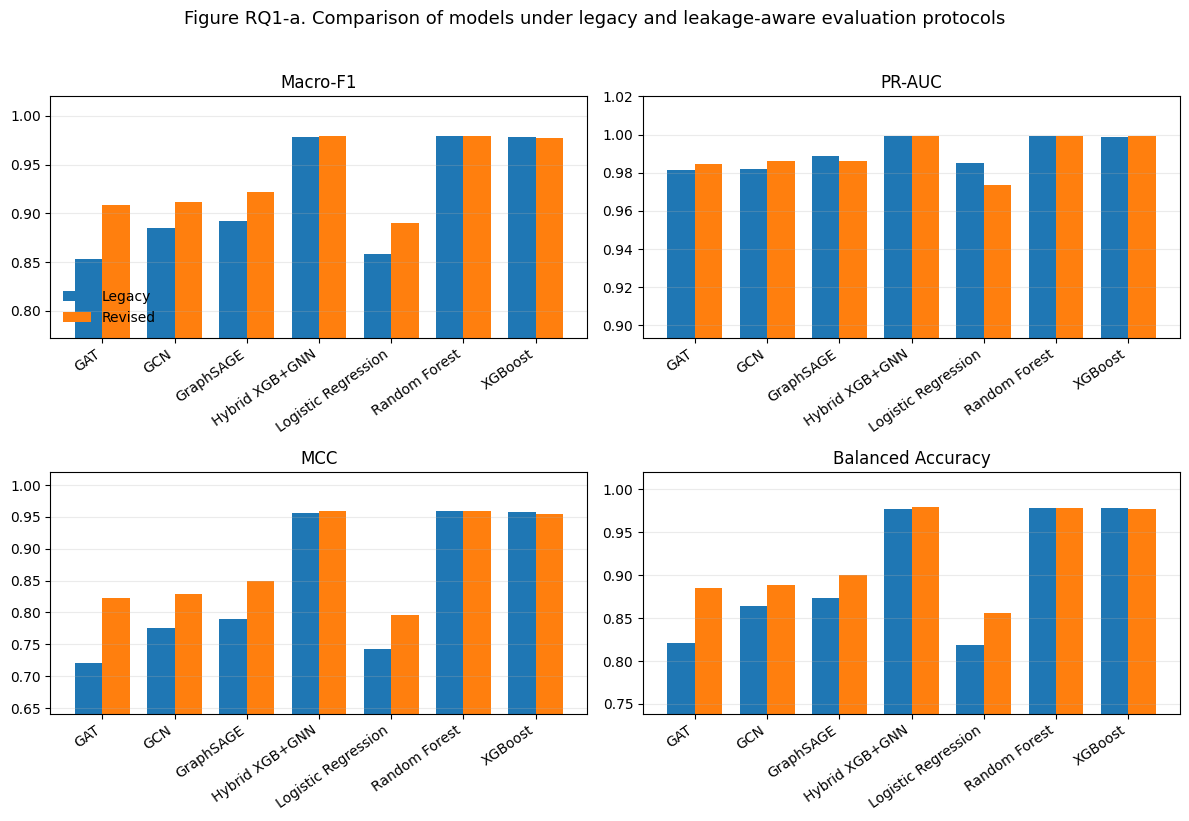

Saved:
outputs/rq1_figures/figure_rq1_a_grouped_comparison.png
outputs/rq1_figures/figure_rq1_a_grouped_comparison.pdf


In [15]:

plot_df = benchmark_rq1.copy()

# Restrict to the metrics explicitly named in the proposal figure
metrics_to_plot = ["Macro-F1", "PR-AUC", "MCC", "Balanced Accuracy"]

available_models = plot_df["Model"].unique().tolist()
n_metrics = len(metrics_to_plot)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    pivot = plot_df.pivot(index="Model", columns="Protocol", values=metric).reindex(available_models)
    x = np.arange(len(pivot.index))
    width = 0.38

    legacy_vals = pivot["Legacy"] if "Legacy" in pivot.columns else np.repeat(np.nan, len(x))
    revised_vals = pivot["Revised"] if "Revised" in pivot.columns else np.repeat(np.nan, len(x))

    ax.bar(x - width/2, legacy_vals, width=width, label="Legacy")
    ax.bar(x + width/2, revised_vals, width=width, label="Revised")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=35, ha="right")
    ax.set_title(metric)
    ax.set_ylim(max(0, np.nanmin(np.r_[legacy_vals, revised_vals]) - 0.08), 1.02)
    ax.grid(axis="y", alpha=0.25)

axes[0].legend(frameon=False, loc="lower left")
fig.suptitle(
    "Figure RQ1-a. Comparison of models under legacy and leakage-aware evaluation protocols",
    fontsize=13, y=1.02
)
fig.tight_layout()

fig1_png = RQ1_FIG_DIR / "figure_rq1_a_grouped_comparison.png"
fig1_pdf = RQ1_FIG_DIR / "figure_rq1_a_grouped_comparison.pdf"
fig.savefig(fig1_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig1_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig1_png)
print(fig1_pdf)


## 10. Generate Figure RQ1-b (workflow diagram) and save as PDF

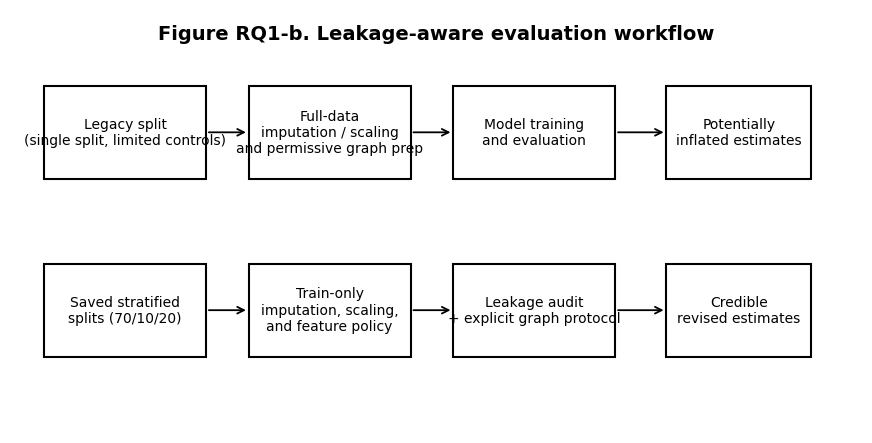

Saved:
outputs/rq1_figures/figure_rq1_b_workflow.png
outputs/rq1_figures/figure_rq1_b_workflow.pdf


In [16]:

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axis("off")

boxes = [
    (0.04, 0.60, 0.19, 0.22, "Legacy split\n(single split, limited controls)"),
    (0.28, 0.60, 0.19, 0.22, "Full-data\nimputation / scaling\nand permissive graph prep"),
    (0.52, 0.60, 0.19, 0.22, "Model training\nand evaluation"),
    (0.77, 0.60, 0.17, 0.22, "Potentially\ninflated estimates"),
    (0.04, 0.18, 0.19, 0.22, "Saved stratified\nsplits (70/10/20)"),
    (0.28, 0.18, 0.19, 0.22, "Train-only\nimputation, scaling,\nand feature policy"),
    (0.52, 0.18, 0.19, 0.22, "Leakage audit\n+ explicit graph protocol"),
    (0.77, 0.18, 0.17, 0.22, "Credible\nrevised estimates")
]

for x0, y0, w0, h0, label in boxes:
    ax.add_patch(Rectangle((x0, y0), w0, h0, fill=False, lw=1.5))
    ax.text(x0 + w0/2, y0 + h0/2, label, ha="center", va="center", fontsize=10)

arrows = [
    ((0.23, 0.71), (0.28, 0.71)),
    ((0.47, 0.71), (0.52, 0.71)),
    ((0.71, 0.71), (0.77, 0.71)),
    ((0.23, 0.29), (0.28, 0.29)),
    ((0.47, 0.29), (0.52, 0.29)),
    ((0.71, 0.29), (0.77, 0.29)),
]
for start, end in arrows:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=12, lw=1.3))

ax.text(0.5, 0.93, "Figure RQ1-b. Leakage-aware evaluation workflow", ha="center", fontsize=14, fontweight="bold")

fig2_png = RQ1_FIG_DIR / "figure_rq1_b_workflow.png"
fig2_pdf = RQ1_FIG_DIR / "figure_rq1_b_workflow.pdf"
fig.savefig(fig2_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig2_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig2_png)
print(fig2_pdf)


## 11. Save a compact RQ1 summary JSON for later reporting

In [17]:

rq1_summary = {
    "dataset_audit": dataset_audit,
    "legacy_protocol_audit": legacy_pack["audit"],
    "revised_protocol_audit": revised_pack["audit"],
    "tables": {
        "rq1_a": str(table1_path),
        "rq1_b": str(table2_path)
    },
    "figures": {
        "rq1_a": str(fig1_pdf),
        "rq1_b": str(fig2_pdf)
    },
    "graph_section_executed": bool(PYG_AVAILABLE)
}

summary_path = RQ1_TABLE_DIR / "rq1_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(rq1_summary, f, indent=2)

print("Saved summary to:", summary_path)
rq1_summary


Saved summary to: outputs/rq1_tables/rq1_summary.json


{'dataset_audit': {'n_rows': 14368,
  'n_cols': 43,
  'label_distribution': {1: 10894, 0: 3474},
  'missingness': {'followers_count': 0.0,
   'friends_count': 0.0,
   'statuses_count': 0.0,
   'favourites_count': 0.0,
   'listed_count': 0.0,
   'default_profile': 0.686,
   'default_profile_image': 0.9946,
   'geo_enabled': 0.7611},
  'duplicate_ids': 0,
  'duplicate_screen_names': 0},
 'legacy_protocol_audit': {'protocol': 'Legacy',
  'full_data_imputation': 'Present',
  'full_data_scaling': 'Present',
  'duplicate_id_overlap': 'Not checked',
  'duplicate_feature_rows_across_split': 273},
 'revised_protocol_audit': {'protocol': 'Revised',
  'full_data_imputation': 'Removed',
  'full_data_scaling': 'Removed',
  'duplicate_id_overlap': 0,
  'duplicate_screen_name_overlap': 0,
  'duplicate_feature_rows_across_split': 264},
 'tables': {'rq1_a': 'outputs/rq1_tables/table_rq1_a_leakage_audit_summary.csv',
  'rq1_b': 'outputs/rq1_tables/table_rq1_b_benchmark_before_after.csv'},
 'figures': {'


## 12. What this notebook produces for RQ1

After running the notebook, you will have:

### Tables
- `table_rq1_a_leakage_audit_summary.csv`
- `table_rq1_b_benchmark_before_after.csv`

### Figures
- `figure_rq1_a_grouped_comparison.pdf`
- `figure_rq1_b_workflow.pdf`

### Notes
- The **tabular RQ1 pipeline runs immediately**.
- The **graph and hybrid sections require `torch-geometric`**.
- If you want, the next step is to create **RQ2.ipynb** in the same style, continuing from the same proposal structure.
